# Complete Energy-Profile Comparison — LaTeX tables & boxplot

Same distance-to-real feature scorecard as `results_energy_profile_compare`, but
adds:
1. the **aggregated** scorecard as LaTeX,
2. one scorecard **per process** (separated) as LaTeX, and
3. a **boxplot across all processes** (per method), styled like the sMAE boxplot
   in `results_latex_table`.

Methods: Alpha, Combined-best, Budget (process types, best duration approach per
process), plus Schedule-direct and Profile-generator. Metric = relative
Wasserstein distance to real of each per-curve feature; **lower = closer to real**.

The first column, **Time**, is the `W1 (time), rel.` metric from
`results_latex_table`: a *paired* per-case comparison of **when** the energy is
drawn, normalized by each case's own real duration. All the other columns are
*distributional* comparisons of a per-curve shape feature (Total, Peak, …).

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
import os, glob, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import wasserstein_distance
from IPython.display import display, Markdown
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')

EXPERIMENT     = 963
CURVE_APPROACH = 'ml_exog_prev_activity'
DURATION_MODE  = 'best_by_mae'    # per-process best time prediction, chosen on SELECTION_SPLIT
                                  # (or fix it: 'baseline' / 'ml_global' / 'ml_local')
DURATION_SELECT_METRIC = 'duration_metrics_activity_duration_mae'
PROCESS_TYPES  = {'Alpha': True, 
                  'Combined-best': True, 
                  'Budget': True}
EXTRA_METHODS  = {'Schedule-direct': True, 'Profile-generator': True}
DISABLED_MINERS = ['wip_aware', 'wip_branching_aware']
# Model selection ALWAYS happens on TRAIN, independently of SPLIT (which only
# controls what the tables report). Selecting on the split being reported would
# let a model be chosen for fitting the evaluation data.
SELECTION_SPLIT = 'train'

SELECTION_METRIC_BASES = [
    'conformance_metrics_fitness',
    'conformance_metrics_precision',
    'conformance_metrics_generalization',
    'conformance_metrics_simplicity',
]
# The four selection metrics are QUALITY scores (higher = better), so the best
# model is the argmax of their average -- not the argmin used when the criterion
# was expressed as errors.
SELECTION_HIGHER_IS_BETTER = True
COMPOSITE_INCLUDE_TIME = True   # fold W1(time) into the composite boxplot score
SAVE_LATEX = True

results_root = Path('..') / 'results'
runs = sorted([d for d in results_root.iterdir()
               if d.is_dir() and d.name.startswith(f'experiment_{EXPERIMENT}_')])
assert runs, f'No runs for experiment {EXPERIMENT}'
RUN = runs[-1]
print('Using run:', RUN.name)
SCHEDULE_SERIES = {'schedule': 'Schedule-direct', 'stochastic': 'Profile-generator'}
_curve_suffix = '' if CURVE_APPROACH in ('baseline', '', None) else f'_{CURVE_APPROACH}'

Using run: experiment_963_20260722_180634


In [2]:
# ── Per-curve features (adds 'median') ───────────────────────────────────────
def curve_features(v):
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    if v.size < 4: return None
    rng = np.nanmax(v) - np.nanmin(v)
    zero = np.mean((v - np.nanmin(v)) <= (0.02 * rng if rng > 0 else 1e-9))
    ac1 = pd.Series(v).autocorr(lag=1)
    return {'total': float(np.nansum(v)), 'peak': float(np.nanmax(v)),
            'mean': float(np.nanmean(v)), 'median': float(np.nanmedian(v)),
            'std': float(np.nanstd(v)), 'ac1': float(ac1) if np.isfinite(ac1) else np.nan,
            'roughness': float(np.nanmean(np.abs(np.diff(v)))), 'zero_frac': float(zero)}

# 'time' is NOT a per-curve shape feature but a paired per-case metric (see
# w1_time_case below). It is carried in the same grid so it shows up as one more
# column in every table / boxplot; VALUE_FEATURES is what curve_features emits.
VALUE_FEATURES = ['total', 'peak', 'mean', 'median', 'std', 'ac1', 'roughness', 'zero_frac']
FEATURES   = ['time'] + VALUE_FEATURES
FEAT_LABEL = {'time':'Time','total':'Total','peak':'Peak','mean':'Mean','median':'Median',
              'std':'Std','ac1':'AC1','roughness':'Roughness','zero_frac':'Zero-frac'}

def features_long(df_curves, method_label):
    rows = []
    for (sen, cid), g in df_curves.groupby(['sensor', 'case_id']):
        f = curve_features(g.sort_values('t_minutes')['value'].to_numpy())
        if f:
            f.update(sensor=sen, case_id=cid, series=method_label); rows.append(f)
    return rows

# ── W1(time): the timing metric from `results_latex_table` ───────────────────
# For ONE case: compare *when* the energy is drawn -- the value-weighted
# distribution over time -- in real vs. predicted, with time normalized by that
# case's OWN real duration (so a case that simply runs longer isn't penalized
# for its scale, only for shifting its energy around inside the case).
# Degenerate cases are skipped (NaN) instead of exploding the ratio, mirroring
# the `_cv_ok` / degenerate-scale guards used for the value features.
def w1_time_case(t_real, v_real, t_pred, v_pred):
    w_real = np.clip(v_real, 0, None); w_pred = np.clip(v_pred, 0, None)
    if w_real.sum() <= 0 or w_pred.sum() <= 0: return np.nan     # all-zero curve
    dur = float(np.nanmax(t_real))
    if not np.isfinite(dur) or dur <= 1e-6: return np.nan        # zero-length case
    return float(wasserstein_distance(t_real / dur, t_pred / dur,
                                      u_weights=w_real, v_weights=w_pred))

def time_long(df_curves, real_series, pred_series, method_label):
    # One row per (sensor, case) present in BOTH the real and predicted series.
    rows = []
    for sen, sg in df_curves.groupby('sensor'):
        real_by = {c: g.sort_values('t_minutes')
                   for c, g in sg[sg['series'] == real_series].groupby('case_id')}
        pred_by = {c: g.sort_values('t_minutes')
                   for c, g in sg[sg['series'] == pred_series].groupby('case_id')}
        for cid, rg in real_by.items():
            pg = pred_by.get(cid)
            if pg is None or pg.empty: continue
            val = w1_time_case(rg['t_minutes'].to_numpy(float), rg['value'].to_numpy(float),
                               pg['t_minutes'].to_numpy(float), pg['value'].to_numpy(float))
            if np.isfinite(val):
                rows.append({'sensor': sen, 'case_id': cid, 'method': method_label,
                             'w1_time': val})
    return rows

In [3]:
# ── Resolve process-type -> concrete simulation mode per process ─────────────
pe = pd.read_parquet(RUN / 'process_eval_results.parquet')
# NOTE: no display-split prefix is needed here — every column read from `pe` in
# this cell drives a SELECTION, and selections use _sel_prefix (TRAIN).
def parse_mode(m):
    r = str(m)[len('petri_net_'):] if str(m).startswith('petri_net_') else str(m)
    if r.endswith('_ml_plus_global'): return r[:-len('_ml_plus_global')], 'ml_global'
    if r.endswith('_ml_plus_per_act'): return r[:-len('_ml_plus_per_act')], 'ml_local'
    return r, 'baseline'
pe['model'], pe['time_pred'] = zip(*pe['mode'].map(parse_mode))
pe = pe[~pe['model'].isin(DISABLED_MINERS)]
_sel_prefix = SELECTION_SPLIT.lower() + '_'          # selection on TRAIN
_sel_cols = [_sel_prefix + b for b in SELECTION_METRIC_BASES
             if (_sel_prefix + b) in pe.columns]
assert _sel_cols, f'no {_sel_prefix}* selection columns found'
_cands = sorted(set(pe['model'].unique()) - {'alpha', 'budget'} - set(DISABLED_MINERS))
best_miner = {}
for proc, g in pe.groupby('process'):
    gc = g[g['model'].isin(_cands)]
    _sc = gc.groupby('model')[_sel_cols].mean().mean(axis=1) if not gc.empty else None
    best_miner[proc] = (None if _sc is None else
                        (_sc.idxmax() if SELECTION_HIGHER_IS_BETTER else _sc.idxmin()))
_TIME_SUFFIX = {'baseline':'', 'ml_global':'_ml_plus_global', 'ml_local':'_ml_plus_per_act'}
# DURATION_MODE='best_by_mae' picks the time-prediction variant per process by
# DURATION_SELECT_METRIC (activity-duration MAE). That is a SELECTION, so it
# reads the TRAIN column -- the tables below report the chosen variant on test,
# and picking it on test would be selecting on the evaluation split (same rule
# as SELECTION_SPLIT above). MAE rather than WAPE: the comparison is always
# within one process, where the scale is constant, so the normalisation WAPE
# adds buys nothing and MAE stays in interpretable minutes.
_dur_sel_col = _sel_prefix + DURATION_SELECT_METRIC
assert _dur_sel_col in pe.columns, f'{_dur_sel_col} missing'
def model_for(proc, ptype):
    return {'Alpha':'alpha','Budget':'budget'}.get(ptype) or best_miner.get(proc)
def mode_for(proc, ptype):
    model = model_for(proc, ptype)
    if model is None: return None
    if DURATION_MODE in _TIME_SUFFIX: tp = DURATION_MODE
    else:
        sub = pe[(pe['process']==proc)&(pe['model']==model)]
        tp = (sub.loc[sub[_dur_sel_col].idxmin(), 'time_pred']
              if not sub.empty and sub[_dur_sel_col].notna().any() else 'baseline')
    return f'petri_net_{model}{_TIME_SUFFIX[tp]}'

In [4]:
# ── Build unified feature table (real + every method) ────────────────────────
active_ptypes = [t for t in ['Alpha','Combined-best','Budget'] if PROCESS_TYPES.get(t)]
active_extra  = [s for s,lbl in SCHEDULE_SERIES.items() if EXTRA_METHODS.get(lbl)]
METHOD_ORDER  = active_ptypes + [SCHEDULE_SERIES[s] for s in active_extra]

all_rows, time_rows = [], []
for proc in sorted(pe['process'].unique()):
    for ptype in active_ptypes:
        mode = mode_for(proc, ptype)
        fp = RUN/'complete_curve_eval_results'/proc/(mode or '')/f'predicted_curves{_curve_suffix}.parquet'
        if not mode or not fp.exists(): continue
        d = pd.read_parquet(fp)
        recs = features_long(d[d['series']=='predicted'], ptype)
        for r in recs: r['process']=proc
        all_rows += recs
        # W1(time): pair each simulated case against its own real counterpart
        for r in time_long(d, 'real', 'predicted', ptype): r['process']=proc; time_rows.append(r)
    sfp = RUN/'schedule_profile_eval_results'/proc/'predicted_curves.parquet'
    if not sfp.exists(): continue
    sdf = pd.read_parquet(sfp)
    for r in (rr for rr in features_long(sdf[sdf['series']=='real'], 'real')): r['process']=proc; all_rows.append(r)
    for s in active_extra:
        recs = features_long(sdf[sdf['series']==s], SCHEDULE_SERIES[s])
        for r in recs: r['process']=proc
        all_rows += recs
        for r in time_long(sdf, 'real', s, SCHEDULE_SERIES[s]): r['process']=proc; time_rows.append(r)
feat = pd.DataFrame(all_rows)
tim  = pd.DataFrame(time_rows)

# restrict to sensors common to real + every method within each process
keep, keep_t = [], []
for proc, g in feat.groupby('process'):
    sets = [set(g[g.series==m]['sensor'].unique()) for m in (['real']+METHOD_ORDER) if m in set(g.series)]
    common = set.intersection(*sets) if sets else set()
    keep.append(g[g['sensor'].isin(common)])
    if not tim.empty:
        gt = tim[tim['process']==proc]
        keep_t.append(gt[gt['sensor'].isin(common)])
feat = pd.concat(keep, ignore_index=True)
tim  = pd.concat(keep_t, ignore_index=True) if keep_t else tim
print('feat rows:', len(feat), '| W1(time) case rows:', len(tim), '| methods:', METHOD_ORDER)

feat rows: 16455 | W1(time) case rows: 13855 | methods: ['Alpha', 'Combined-best', 'Budget', 'Schedule-direct', 'Profile-generator']


In [5]:
# ── Relative W1-to-real per (process, sensor, method, feature) — the raw grid ─
records = []
for (proc, sen), g in feat.groupby(['process', 'sensor']):
    for feature in VALUE_FEATURES:
        r = g[g.series=='real'][feature].dropna().to_numpy()
        if len(r) < 2: continue
        scale = np.nanmean(np.abs(r)) + 1e-9
        # Degenerate-scale guard: for zero-inflated energy sensors the per-case
        # 'median' (and occasionally others) is ~0 for every real case, so
        # mean|real| collapses and the relative W1 explodes. Skip those cells
        # (they show '—') rather than emit meaningless ~1e9 values.
        if scale < 1e-6:
            continue
        for m in METHOD_ORDER:
            q = g[g.series==m][feature].dropna().to_numpy()
            if len(q) < 2: continue
            records.append({'process':proc,'sensor':sen,'method':m,'feature':feature,
                            'rel_w1': wasserstein_distance(r, q)/scale})
w1 = pd.DataFrame(records)

# W1(time) enters the same grid: median across the cases of each (process,
# sensor, method) cell, so it aggregates exactly like the value features.
if not tim.empty:
    t_cells = (tim.groupby(['process','sensor','method'])['w1_time'].median()
                  .reset_index(name='rel_w1'))
    t_cells['feature'] = 'time'
    w1 = pd.concat([w1, t_cells[['process','sensor','method','feature','rel_w1']]],
                   ignore_index=True)
print('W1 grid rows:', len(w1), '| of which time:', int((w1.feature=='time').sum()))

def scorecard(df_w1):
    t = (df_w1.groupby(['method','feature'])['rel_w1'].median().unstack('feature')
             .reindex(index=METHOD_ORDER, columns=FEATURES))
    t.columns = [FEAT_LABEL[c] for c in t.columns]
    t.index.name = 'Method'
    return t

def style_score(tbl):
    return (tbl.style.format('{:.3f}', na_rep='—')
              .highlight_min(axis=0, props='font-weight:700;background-color:#d6ecff;')
              .set_caption('Relative W1 to real (median over process×sensor) — lower = closer to real'))

W1 grid rows: 3530 | of which time: 400


### What each metric means

Every cell of the grid is one **(process, sensor, method)** pair; the tables show the
**median** of those cells. Two different kinds of quantity share the grid:

**`Time` — paired, per case.** For each case, the curve is read as a distribution of
energy over time (each sample weighted by its value), with time rescaled by *that
case's own real duration* (so `0 = case start`, `1 = real case end`). The value is the
Wasserstein distance between the real and the predicted version of that distribution,
i.e. *"on average, by what fraction of the case length is the predicted energy shifted
relative to the real energy?"*. `0.06` ≈ energy arrives 6 % of a case-length off.
It penalizes both shifted activities and a case that finishes too early/late.
Skipped when the real curve is all-zero or the case has zero duration.

**All other columns — distributional, per feature.** For each case a single scalar is
computed from its curve; that gives one distribution over cases for `real` and one for
the method. The number is `W1(real, method) / mean|real|` — the shift between those two
distributions, expressed as a fraction of the typical real value, so it is comparable
across sensors with wildly different units. Cells where `mean|real|` collapses to ~0
(zero-inflated sensors) are dropped rather than reported as huge nonsense.

| Column | Per-curve scalar | Reads as |
|---|---|---|
| `Total` | `sum(v)` | total energy drawn over the case — gets the **overall consumption** right |
| `Peak` | `max(v)` | highest instantaneous load — matters for **peak demand / connection sizing** |
| `Mean` | `mean(v)` | average load level over the case |
| `Median` | `median(v)` | *typical* load level, robust to spikes; for on/off sensors this is essentially the **idle / base level** |
| `Std` | `std(v)` | how much the load swings within a case — **amplitude of the dynamics** |
| `AC1` | `corr(v_t, v_{t-1})` | lag-1 autocorrelation: **persistence/smoothness**. ~1 = smooth ramps, ~0 = noisy sample-to-sample. Low error here = the method reproduces how *gradually* load changes |
| `Roughness` | `mean|Δv|` | mean absolute step between consecutive samples — **jaggedness / switching intensity**. A method that adds high-frequency noise blows up here even if Mean/Total are perfect |
| `Zero-frac` | share of samples within 2 % of the curve's own range above its minimum | **duty cycle**: fraction of the case spent at the floor/idle level vs. actually running |

`AC1` and `Roughness` are the two *shape* metrics (are the dynamics realistic?);
`Total`/`Peak`/`Mean`/`Median`/`Std` are *level* metrics (is the magnitude realistic?);
`Zero-frac` is a *duty-cycle* metric; `Time` is the *timing* metric. Lower is better
everywhere.

## 1 · Aggregated scorecard (all processes)

In [6]:
score_all = scorecard(w1)
display(style_score(score_all))

,Time,Total,Peak,Mean,Median,Std,AC1,Roughness,Zero-frac
Method,,,,,,,,,
Alpha,0.307,0.364,0.128,0.175,0.143,0.551,0.138,0.845,0.802
Combined-best,0.247,0.470,0.141,0.155,0.118,0.562,0.194,0.836,1.047
Budget,0.094,0.226,0.129,0.161,0.119,0.604,0.210,0.860,0.849
Schedule-direct,0.059,0.679,0.144,0.161,0.115,0.784,0.464,0.795,0.806
Profile-generator,0.060,0.677,0.240,0.167,0.116,1.472,0.963,24.951,0.776


## 2 · Per process (separated)

In [7]:
per_process_scores = {}
for proc in sorted(w1['process'].unique()):
    s = scorecard(w1[w1['process']==proc])
    per_process_scores[proc] = s
    display(Markdown(f'### {proc}'))
    display(style_score(s))

### process_1

,Time,Total,Peak,Mean,Median,Std,AC1,Roughness,Zero-frac
Method,,,,,,,,,
Alpha,0.071,0.285,0.124,0.840,20.318,0.152,0.091,0.817,0.134
Combined-best,0.041,0.148,0.094,0.624,2.177,0.175,0.038,0.581,0.108
Budget,0.037,0.234,0.119,0.767,2.133,0.169,0.122,0.862,0.118
Schedule-direct,0.138,0.501,0.143,0.484,0.776,0.452,0.309,0.354,0.084
Profile-generator,0.120,0.322,0.299,0.311,1.365,0.113,0.424,3.397,0.180


### process_2

,Time,Total,Peak,Mean,Median,Std,AC1,Roughness,Zero-frac
Method,,,,,,,,,
Alpha,0.229,0.761,0.330,0.430,256.398,0.297,0.067,0.391,0.239
Combined-best,0.267,0.353,0.246,0.392,183.379,0.327,0.064,0.273,0.117
Budget,0.188,0.619,0.251,0.408,228.622,0.314,0.059,0.287,0.219
Schedule-direct,0.182,0.798,0.254,0.781,37.219,0.646,0.099,0.604,0.036
Profile-generator,0.179,0.885,0.231,0.655,2147.617,0.276,0.836,3.597,0.528


### process_3

...

,Time,Total,Peak,Mean,Median,Std,AC1,Roughness,Zero-frac
Method,,,,,,,,,
Alpha,0.315,0.550,0.059,0.103,0.104,0.667,0.217,0.942,2.621
Combined-best,0.238,0.363,0.077,0.104,0.105,0.683,0.188,0.866,9.409
Budget,0.095,0.184,0.058,0.104,0.105,0.643,0.242,0.754,1.261
Schedule-direct,0.017,0.322,0.085,0.066,0.077,0.862,0.494,0.952,0.911
Profile-generator,0.017,0.351,0.206,0.069,0.072,1.530,0.993,18.364,0.748


### process_4_2

,Time,Total,Peak,Mean,Median,Std,AC1,Roughness,Zero-frac
Method,,,,,,,,,
Alpha,0.249,0.170,0.150,0.120,0.131,0.722,0.195,1.223,1.173
Combined-best,0.246,0.465,0.135,0.116,0.126,0.644,0.254,0.873,1.801
Budget,0.099,0.225,0.134,0.115,0.128,0.734,0.268,0.849,0.975
Schedule-direct,0.016,0.417,0.092,0.130,0.138,0.783,0.199,0.955,0.928
Profile-generator,0.016,0.446,0.096,0.166,0.174,1.407,0.986,10.419,0.921


### process_5

,Time,Total,Peak,Mean,Median,Std,AC1,Roughness,Zero-frac
Method,,,,,,,,,
Alpha,0.313,0.348,0.132,0.117,0.127,0.579,0.105,0.507,0.774
Combined-best,0.391,0.474,0.148,0.097,0.112,0.653,0.238,1.717,1.204
Budget,0.088,0.192,0.145,0.100,0.111,0.661,0.231,2.050,1.003
Schedule-direct,0.061,0.705,0.132,0.091,0.097,0.823,0.526,0.691,0.819
Profile-generator,0.063,0.707,0.334,0.102,0.108,2.067,0.950,38.370,0.837


## 3 · LaTeX — aggregated + one table per process

In [8]:
def to_latex_score(tbl, caption, label):
    str_df = pd.DataFrame(index=tbl.index, columns=tbl.columns, dtype=object)
    for col in tbl.columns:
        vals = tbl[col].dropna(); best = vals.min() if not vals.empty else None
        for idx in tbl.index:
            v = tbl.loc[idx, col]
            if pd.isna(v): str_df.loc[idx, col] = '--'
            else:
                s = f'{v:.3f}'
                str_df.loc[idx, col] = (r'\textbf{'+s+'}') if (best is not None and abs(v-best)<1e-9) else s
    latex = str_df.to_latex(escape=False, column_format='l|'+'|'.join(['c']*len(tbl.columns)),
                            caption=caption, label=label, position='H')
    return latex.replace('_', r'\_')

out = RUN/'process_metrics_tables'
if SAVE_LATEX: out.mkdir(exist_ok=True)

tex_all = to_latex_score(score_all,
    caption=(f'Complete energy-profile comparison ({CURVE_APPROACH} curves), all processes. '
             r'Median over (process, sensor) of the relative Wasserstein distance to real per '
             r'feature; lower = closer to real. \textbf{Bold} = closest to real per feature.'),
    label=f'tab:energy_profile_all_{EXPERIMENT}')
if SAVE_LATEX: (out/'energy_profile_all.tex').write_text(tex_all)
print('% ===== ALL PROCESSES ====='); print(tex_all)

for proc, s in per_process_scores.items():
    tex = to_latex_score(s,
        caption=(f'Complete energy-profile comparison for {proc} ({CURVE_APPROACH} curves). '
                 r'Median over sensors of the relative Wasserstein distance to real per feature; '
                 r'lower = closer to real. \textbf{Bold} = closest to real per feature.'),
        label=f'tab:energy_profile_{proc}_{EXPERIMENT}')
    if SAVE_LATEX: (out/f'energy_profile_{proc}.tex').write_text(tex)
    print(f'\n% ===== {proc} ====='); print(tex)
if SAVE_LATEX: print('\nSaved per-process + aggregated .tex to', out)

% ===== ALL PROCESSES =====
\begin{table}[H]
\caption{Complete energy-profile comparison (ml\_exog\_prev\_activity curves), all processes. Median over (process, sensor) of the relative Wasserstein distance to real per feature; lower = closer to real. \textbf{Bold} = closest to real per feature.}
\label{tab:energy\_profile\_all\_963}
\begin{tabular}{l|c|c|c|c|c|c|c|c|c}
\toprule
 & Time & Total & Peak & Mean & Median & Std & AC1 & Roughness & Zero-frac \\
Method &  &  &  &  &  &  &  &  &  \\
\midrule
Alpha & 0.307 & 0.364 & \textbf{0.128} & 0.175 & 0.143 & \textbf{0.551} & \textbf{0.138} & 0.845 & 0.802 \\
Combined-best & 0.247 & 0.470 & 0.141 & \textbf{0.155} & 0.118 & 0.562 & 0.194 & 0.836 & 1.047 \\
Budget & 0.094 & \textbf{0.226} & 0.129 & 0.161 & 0.119 & 0.604 & 0.210 & 0.860 & 0.849 \\
Schedule-direct & \textbf{0.059} & 0.679 & 0.144 & 0.161 & \textbf{0.115} & 0.784 & 0.464 & \textbf{0.795} & 0.806 \\
Profile-generator & 0.060 & 0.677 & 0.240 & 0.167 & 0.116 & 1.472 & 0.963 & 24.9

## 4 · Boxplot across all processes

Composite realism distance per (process, sensor): the **median across features**
of the relative W1-to-real (Time included when `COMPOSITE_INCLUDE_TIME`). One box
per method over all (process, sensor) — same horizontal style as the sMAE
boxplot. Lower (left) = closer to real.

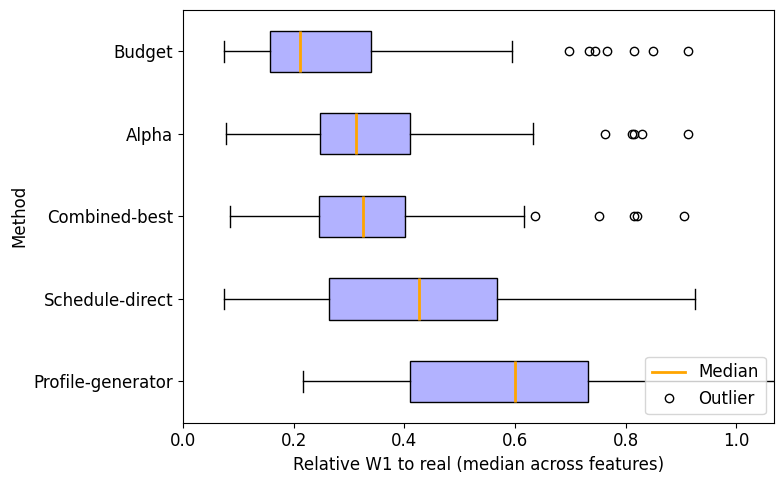

Saved: visuals/energy_profile_W1_boxplot.pdf and ../results/experiment_963_20260722_180634/plots/energy_profile_W1_boxplot.png


In [9]:
# composite per (process, sensor, method) = median across features
_w1c = w1 if COMPOSITE_INCLUDE_TIME else w1[w1.feature != 'time']
comp = (_w1c.groupby(['process','sensor','method'])['rel_w1'].median().reset_index(name='val'))

plt.rcParams.update({'font.size': 12})
box_order = comp.groupby('method')['val'].median().sort_values(ascending=False).index.tolist()
data = [comp.loc[comp.method==m, 'val'].dropna().values for m in box_order]

fig, ax = plt.subplots(figsize=(8, 5))
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False,
                   patch_artist=True, medianprops=dict(color='orange', linewidth=2))
blue = mcolors.to_rgba('blue', alpha=0.3)
for patch in bplot['boxes']:
    patch.set_facecolor(blue); patch.set_edgecolor('black')
all_vals = np.concatenate([d for d in data if len(d)])
ax.set_xlim(0, np.percentile(all_vals, 95) * 1.3)
ax.set_xlabel('Relative W1 to real (median across features)')
ax.set_ylabel('Method')
ax.legend(handles=[Line2D([0],[0],color='orange',lw=2,label='Median'),
                   Line2D([0],[0],marker='o',color='w',markeredgecolor='black',
                          markerfacecolor='none',markersize=6,label='Outlier')],
          loc='lower right')
fig.tight_layout()
Path('visuals').mkdir(exist_ok=True)
fig.savefig('visuals/energy_profile_W1_boxplot.pdf', dpi=300, bbox_inches='tight')
(RUN/'plots').mkdir(exist_ok=True)
fig.savefig(RUN/'plots'/'energy_profile_W1_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: visuals/energy_profile_W1_boxplot.pdf and', RUN/'plots'/'energy_profile_W1_boxplot.png')

### Per-feature boxplots (the individual metrics)

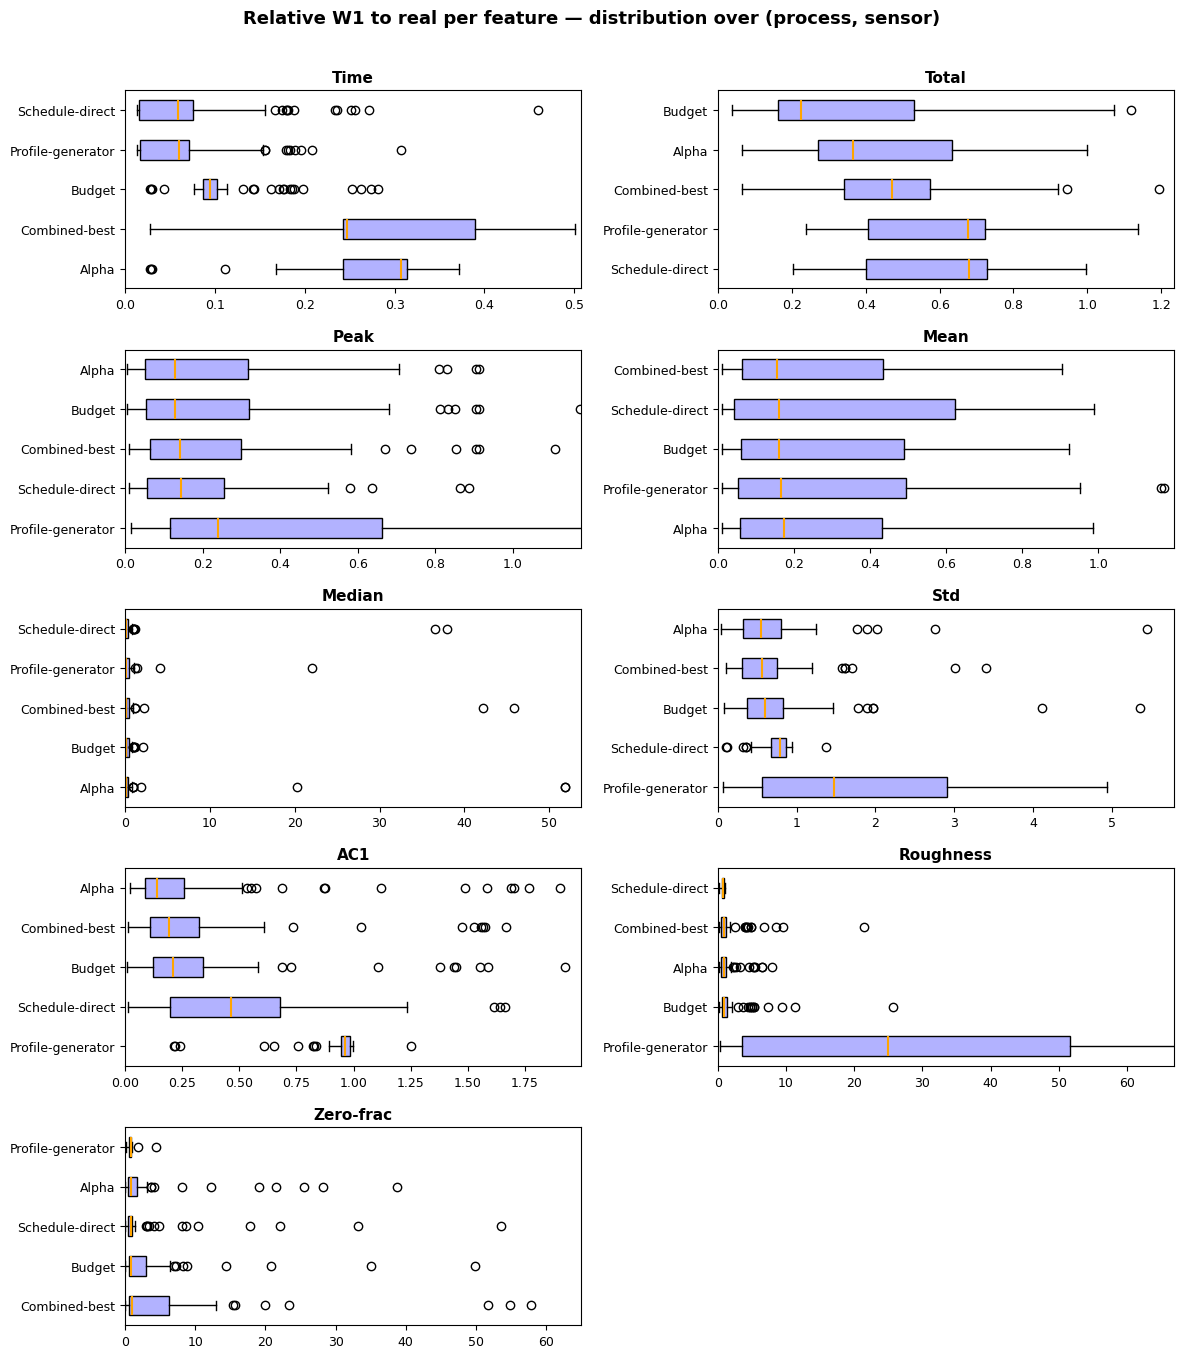

In [10]:
feats = FEATURES
ncol = 2; nrow = int(np.ceil(len(feats)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 2.7*nrow))
axes = np.array(axes).reshape(-1)
for ax, feature in zip(axes, feats):
    sub = w1[w1.feature==feature]
    order = sub.groupby('method')['rel_w1'].median().sort_values(ascending=False).index.tolist()
    data = [sub.loc[sub.method==m,'rel_w1'].dropna().values for m in order]
    bp = ax.boxplot(data, tick_labels=order, showfliers=True, vert=False, patch_artist=True,
                    medianprops=dict(color='orange', linewidth=1.5))
    for patch in bp['boxes']:
        patch.set_facecolor(mcolors.to_rgba('blue', alpha=0.3)); patch.set_edgecolor('black')
    av = np.concatenate([d for d in data if len(d)])
    if len(av): ax.set_xlim(0, np.percentile(av, 95)*1.3)
    ax.set_title(FEAT_LABEL[feature], fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=9)
for ax in axes[len(feats):]:
    ax.axis('off')
fig.suptitle('Relative W1 to real per feature — distribution over (process, sensor)',
             fontsize=13, fontweight='bold', y=1.005)
fig.tight_layout()
fig.savefig(RUN/'plots'/'energy_profile_W1_boxplot_per_feature.png', dpi=130, bbox_inches='tight')
plt.show()